In [1]:
# ==========================================================
# Imports
# ==========================================================

from pathlib import Path

import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import random
import numpy as np
import torch

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
PROJECT_PATH = Path("/content/drive/MyDrive/UAH_Project")

DATASET_PATH = (
    PROJECT_PATH
    / "datasets"
    / "processed"
    / "uah_dataset_window160.npz"
)

sensor_data = np.load(DATASET_PATH)

X = sensor_data["X"]
y = sensor_data["y"]
groups = sensor_data["groups"]

print(X.shape)

(30516, 160, 13)


In [5]:
unique_groups = np.unique(groups)

trip_labels = np.array([
    y[groups == trip][0]
    for trip in unique_groups
])

train_groups, test_groups = train_test_split(
    unique_groups,
    test_size=0.20,
    random_state=42,
    stratify=trip_labels,
)

In [6]:
train_mask = np.isin(
    groups,
    train_groups,
)

test_mask = np.isin(
    groups,
    test_groups,
)

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

In [7]:
print(X_train.shape)
print(X_test.shape)

(24597, 160, 13)
(5919, 160, 13)


In [8]:
from sklearn.preprocessing import StandardScaler

# (samples, timesteps, features)
n_train, seq_len, n_features = X_train.shape
n_test = X_test.shape[0]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train.reshape(-1, n_features)
).reshape(n_train, seq_len, n_features)

X_test_scaled = scaler.transform(
    X_test.reshape(-1, n_features)
).reshape(n_test, seq_len, n_features)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(24597, 160, 13)
(5919, 160, 13)


In [9]:
from torch.utils.data import Dataset

class DriverDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [10]:
from torch.utils.data import DataLoader

batch_size = 32

train_dataset = DriverDataset(X_train_scaled, y_train)
test_dataset = DriverDataset(X_test_scaled, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [11]:
import torch.nn as nn

class LSTMClassifier(nn.Module):

    def __init__(
        self,
        input_size=13,
        hidden_size=64,
        num_layers=2,
        num_classes=3,
        dropout=0.3
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        output, (hidden, cell) = self.lstm(x)

        x = hidden[-1]

        x = self.dropout(x)

        x = self.fc(x)

        return x

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


In [13]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print(class_weights)

tensor([0.8212, 0.9865, 1.3010])


In [14]:
model = LSTMClassifier().to(device)

In [15]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

In [16]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [18]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    loss = running_loss / len(loader)

    acc = accuracy_score(all_labels, all_preds)

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    return loss, acc, macro_f1, all_labels, all_preds

In [19]:
import copy

num_epochs = 20
patience = 3

best_model = None
best_f1 = 0.0
patience_counter = 0

train_losses = []
test_losses = []

train_accs = []
test_accs = []

test_f1s = []

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    test_loss, test_acc, test_f1, _, _ = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    test_f1s.append(test_f1)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f} | "
        f"Macro F1: {test_f1:.4f}"
    )

    if test_f1 > best_f1:

        best_f1 = test_f1
        patience_counter = 0

        best_model = copy.deepcopy(model.state_dict())


    else:

        patience_counter += 1

    if patience_counter >= patience:

        print("\nEarly stopping!")
        break

Epoch 01/20 | Train Loss: 0.9163 | Train Acc: 0.5051 | Test Loss: 0.8654 | Test Acc: 0.5325 | Macro F1: 0.5356
Epoch 02/20 | Train Loss: 0.7114 | Train Acc: 0.6657 | Test Loss: 0.8238 | Test Acc: 0.5996 | Macro F1: 0.6059
Epoch 03/20 | Train Loss: 0.6347 | Train Acc: 0.7129 | Test Loss: 0.7752 | Test Acc: 0.6055 | Macro F1: 0.6280
Epoch 04/20 | Train Loss: 0.5939 | Train Acc: 0.7312 | Test Loss: 0.7477 | Test Acc: 0.6768 | Macro F1: 0.6861
Epoch 05/20 | Train Loss: 0.5613 | Train Acc: 0.7475 | Test Loss: 0.5993 | Test Acc: 0.7366 | Macro F1: 0.7183
Epoch 06/20 | Train Loss: 0.5300 | Train Acc: 0.7557 | Test Loss: 0.7536 | Test Acc: 0.6555 | Macro F1: 0.6733
Epoch 07/20 | Train Loss: 0.4944 | Train Acc: 0.7745 | Test Loss: 0.8766 | Test Acc: 0.6496 | Macro F1: 0.6692
Epoch 08/20 | Train Loss: 0.4675 | Train Acc: 0.7989 | Test Loss: 0.7546 | Test Acc: 0.6596 | Macro F1: 0.6747

Early stopping!


In [20]:
model.load_state_dict(best_model)

<All keys matched successfully>

In [21]:
test_loss, test_acc, test_f1, y_true, y_pred = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"\nFinal Accuracy : {test_acc:.4f}")
print(f"Final Macro F1 : {test_f1:.4f}")


Final Accuracy : 0.7366
Final Macro F1 : 0.7183


In [22]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

print(cm)

              precision    recall  f1-score   support

           0       0.72      0.80      0.76      2939
           1       0.62      0.46      0.53      1487
           2       0.85      0.88      0.87      1493

    accuracy                           0.74      5919
   macro avg       0.73      0.71      0.72      5919
weighted avg       0.73      0.74      0.73      5919

[[2363  352  224]
 [ 800  686    1]
 [ 114   68 1311]]


# Experiment 2 - Dropout Analysis

In [23]:
# Dropout Experiment (0.2)

model = LSTMClassifier(
    input_size=X_train.shape[2],
    hidden_size=64,
    num_layers=2,
    num_classes=len(np.unique(y)),
    dropout=0.2
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [24]:
from sklearn.metrics import accuracy_score, f1_score

In [25]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        # Gradient Clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    return epoch_loss, epoch_acc, epoch_f1

In [26]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    return epoch_loss, epoch_acc, epoch_f1

In [27]:
num_epochs = 20

best_f1 = 0
best_model = copy.deepcopy(model.state_dict())
patience = 3
counter = 0

train_losses = []
test_losses = []

train_accs = []
test_accs = []

train_f1s = []
test_f1s = []

for epoch in range(num_epochs):

    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    test_loss, test_acc, test_f1 = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    train_f1s.append(train_f1)
    test_f1s.append(test_f1)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}")
    print(f"Test  Loss: {test_loss:.4f} | Acc: {test_acc:.4f} | F1: {test_f1:.4f}")

    if test_f1 > best_f1:
        best_f1 = test_f1
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping!")
        break

Epoch 1/20
Train Loss: 0.9103 | Acc: 0.5267 | F1: 0.5250
Test  Loss: 0.8626 | Acc: 0.4952 | F1: 0.5089
Epoch 2/20
Train Loss: 0.6853 | Acc: 0.6623 | F1: 0.6709
Test  Loss: 0.8070 | Acc: 0.5612 | F1: 0.5846
Epoch 3/20
Train Loss: 0.6147 | Acc: 0.7013 | F1: 0.7138
Test  Loss: 0.7479 | Acc: 0.5959 | F1: 0.6178
Epoch 4/20
Train Loss: 0.5730 | Acc: 0.7344 | F1: 0.7458
Test  Loss: 0.7176 | Acc: 0.6439 | F1: 0.6602
Epoch 5/20
Train Loss: 0.5403 | Acc: 0.7536 | F1: 0.7647
Test  Loss: 0.7449 | Acc: 0.6253 | F1: 0.6481
Epoch 6/20
Train Loss: 0.5080 | Acc: 0.7695 | F1: 0.7797
Test  Loss: 0.6466 | Acc: 0.7287 | F1: 0.7358
Epoch 7/20
Train Loss: 0.4737 | Acc: 0.7870 | F1: 0.7969
Test  Loss: 0.6852 | Acc: 0.7077 | F1: 0.7143
Epoch 8/20
Train Loss: 0.4473 | Acc: 0.7920 | F1: 0.8022
Test  Loss: 0.7061 | Acc: 0.7096 | F1: 0.7213
Epoch 9/20
Train Loss: 0.4274 | Acc: 0.8012 | F1: 0.8119
Test  Loss: 0.7596 | Acc: 0.6334 | F1: 0.6529
Early stopping!


In [28]:
model.load_state_dict(best_model)

test_loss, test_acc, test_f1 = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print("=" * 50)
print("Dropout = 0.2")
print(f"Final Accuracy : {test_acc:.4f}")
print(f"Final Macro F1 : {test_f1:.4f}")
print("=" * 50)

Dropout = 0.2
Final Accuracy : 0.7287
Final Macro F1 : 0.7358


In [29]:
torch.save(best_model,
           "dropout02.pth")

In [30]:
FEATURE_COLUMNS = [
    "acc_x",
    "acc_y",
    "acc_z",
    "roll",
    "pitch",
    "yaw",
    "speed",
    "heading",
    "lane_offset",
    "phi",
    "front_distance",
    "relative_speed",
    "vehicle_state",
]

In [31]:
from pathlib import Path
import torch

MODEL_DIR = Path("/content/drive/MyDrive/UAH_Project/models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "lstm_window160_dropout02_macrof1_07358.pth"

torch.save(
    {
        "model_state_dict": best_model,
        "hidden_size": 64,
        "num_layers": 2,
        "dropout": 0.2,
        "window_size": 160,
        "macro_f1": best_f1,
        "num_features": 13,
        "num_classes": 3,
        "sequence_length": 160,
        "feature_columns": FEATURE_COLUMNS,
    },
    MODEL_PATH,
)

print(f"✅ Model saved to:\n{MODEL_PATH}")

✅ Model saved to:
/content/drive/MyDrive/UAH_Project/models/lstm_window160_dropout02_macrof1_07358.pth


In [32]:
from pathlib import Path

MODEL_PATH = Path("/content/drive/MyDrive/UAH_Project/models/lstm_window160_dropout02_macrof1_07358.pth")

print(MODEL_PATH.exists())

True


In [34]:
from pathlib import Path
import torch

MODEL_PATH = Path(
    "/content/drive/MyDrive/UAH_Project/models/lstm_window160_dropout02_macrof1_07358.pth"
)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

print(checkpoint.keys())

dict_keys(['model_state_dict', 'hidden_size', 'num_layers', 'dropout', 'window_size', 'macro_f1', 'num_features', 'num_classes', 'sequence_length', 'feature_columns'])


In [35]:
print("Dropout:", checkpoint["dropout"])
print("Window:", checkpoint["window_size"])
print("Macro F1:", checkpoint["macro_f1"])
print("Features:", checkpoint["feature_columns"])

Dropout: 0.2
Window: 160
Macro F1: 0.7357603501786508
Features: ['acc_x', 'acc_y', 'acc_z', 'roll', 'pitch', 'yaw', 'speed', 'heading', 'lane_offset', 'phi', 'front_distance', 'relative_speed', 'vehicle_state']


In [36]:
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [37]:
test_loss, test_acc, test_f1 = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(test_acc)
print(test_f1)

0.7286703835107282
0.7357603501786508


In [38]:
x, y = next(iter(test_loader))

print(x.shape)
print(y.shape)

torch.Size([32, 160, 13])
torch.Size([32])


In [39]:
all_X = []
all_y = []

for x_batch, y_batch in test_loader:
    all_X.append(x_batch)
    all_y.append(y_batch)

X_test = torch.cat(all_X, dim=0)
y_test = torch.cat(all_y, dim=0)

print(X_test.shape)
print(y_test.shape)

torch.Size([5919, 160, 13])
torch.Size([5919])


In [40]:
from sklearn.metrics import f1_score
import numpy as np

def permutation_macro_f1(model, X_test, y_test, feature_idx, device):
    model.eval()

    # Orijinal verinin kopyasını oluştur
    X_perm = X_test.clone()

    # Rastgele örnek sırası oluştur
    perm = torch.randperm(X_perm.size(0))

    # Sadece seçilen feature'ı permüte et
    X_perm[:, :, feature_idx] = X_perm[perm, :, feature_idx]

    with torch.no_grad():
        outputs = model(X_perm.to(device))
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

    f1 = f1_score(
        y_test.numpy(),
        preds,
        average="macro"
    )

    return f1

In [41]:
speed_f1 = permutation_macro_f1(
    model,
    X_test,
    y_test,
    feature_idx=6,
    device=device
)

print("Baseline Macro F1 :", test_f1)
print("Permuted Macro F1 :", speed_f1)
print("Importance :", test_f1 - speed_f1)

Baseline Macro F1 : 0.7357603501786508
Permuted Macro F1 : 0.5138395976602763
Importance : 0.2219207525183745


In [42]:
speed_scores = []

for i in range(5):
    f1 = permutation_macro_f1(
        model,
        X_test,
        y_test,
        feature_idx=6,
        device=device
    )
    speed_scores.append(f1)

print(speed_scores)
print("Mean:", np.mean(speed_scores))
print("Std :", np.std(speed_scores))
print("Importance:", test_f1 - np.mean(speed_scores))

[0.5085267855514681, 0.5028851235215667, 0.5116697011477731, 0.503699137157514, 0.5099151784981529]
Mean: 0.507339185175295
Std : 0.0034608703999932616
Importance: 0.22842116500335585


In [43]:
results = []

for idx, feature_name in enumerate(FEATURE_COLUMNS):

    scores = []

    for _ in range(5):
        f1 = permutation_macro_f1(
            model,
            X_test,
            y_test,
            feature_idx=idx,
            device=device
        )
        scores.append(f1)

    mean_f1 = np.mean(scores)
    std_f1 = np.std(scores)
    importance = test_f1 - mean_f1

    results.append({
        "Feature": feature_name,
        "Mean F1": mean_f1,
        "Std": std_f1,
        "Importance": importance
    })

In [44]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

results_df

,Feature,Mean F1,Std,Importance
0,speed,0.510491,0.008391,0.225269
1,front_distance,0.589862,0.006221,0.145899
2,lane_offset,0.605395,0.003825,0.130365
3,relative_speed,0.615965,0.005311,0.119796
4,vehicle_state,0.660109,0.003254,0.075652
5,heading,0.685124,0.003187,0.050637
6,acc_z,0.703899,0.003109,0.031861
7,roll,0.718636,0.000622,0.017125
8,pitch,0.723234,0.000631,0.012527
9,acc_x,0.725431,0.001602,0.010330


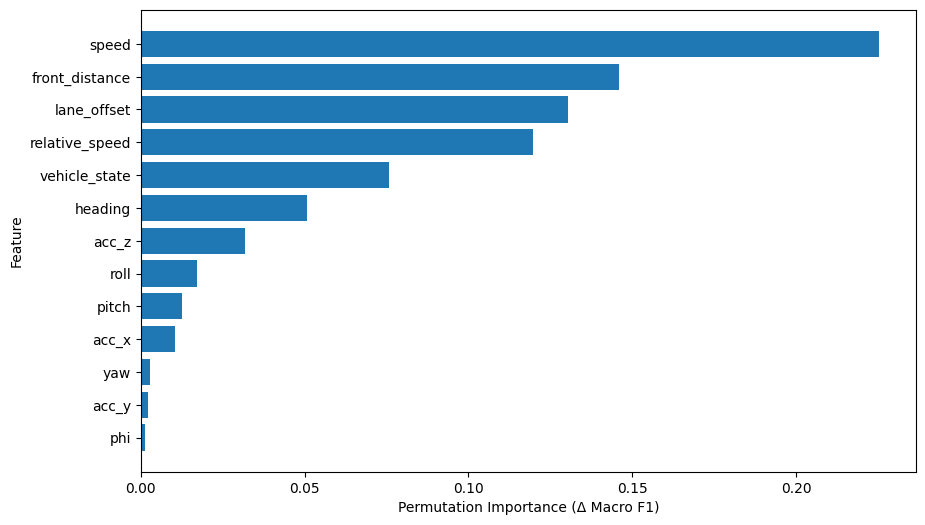

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    results_df["Feature"],
    results_df["Importance"]
)

plt.xlabel("Permutation Importance (Δ Macro F1)")
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()